# Experimentation with model

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

from transformers import AutoTokenizer, set_seed
import os, torch
import sys, argparse, time
import inspect
import numpy as np
from vllm import LLM, SamplingParams

sys.path.append("src") 
from llama_activate import (
    get_llm,
    run_simulation,
    main, 
    call_visualizations,
    pca_visualize
    
)

from utils.path_manager import PathManager

import utils.metrics as metrics
from utils.path_manager import PathManager
from classes.network import RandomNetwork, SocialDistanceAttachment
import utils.load_personas as lp
import utils.visualization as vis
import utils.reading_in as ri
import warnings

# Suppress annoying warning
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas.io.spss")

# --- Model Configuration ---
llama_model = "meta-llama/Meta-Llama-3.1-8B-Instruct" #bigger model
MODEL_ID = os.environ.get("LLAMA_ID", llama_model)
CACHE_DIR = os.environ.get("TRANSFORMERS_CACHE", None)
SEED = 1234
set_seed(SEED)

print("Is CUDA available:", torch.cuda.is_available())

/gpfs/home2/choynck/thesis/ABM_based_LLMS/.venv_vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 04-05 20:49:21 [importing.py:44] Triton is installed but 0 active driver(s) found (expected 1). Disabling Triton to prevent runtime errors.
INFO 04-05 20:49:21 [importing.py:68] Triton not installed or not compatible; certain GPU-related functions will not be available.


[2026-04-05 20:49:26] INFO config.py:58: PyTorch version 2.10.0 available.


Is CUDA available: False


In [ ]:
# # --- Tokenizer Setup ---
# tokenizer = AutoTokenizer.from_pretrained(
#     MODEL_ID,  
#     cache_dir=CACHE_DIR, 
#     use_fast=True, 
# )
# tokenizer.padding_side = "left"
# if tokenizer.pad_token is None:
#     tokenizer.pad_token = tokenizer.eos_token

# os.environ["VLLM_BATCH_INVARIANT"] = "1"

# def get_llm():
#     """Set up the vLLM engine."""
#     print(f"Loading vLLM model: {MODEL_ID}...")
#     llm = LLM(
#         model=MODEL_ID,
#         dtype="bfloat16",
#         trust_remote_code=True,
#         gpu_memory_utilization=0.90,
#         seed=SEED,
#     )
#     return llm

# # Initialize the model
# pipe = get_llm()

### Do prompt robustness analyses


In [ ]:
from src.utils.visualization import load_best_prompts, load_test_scores, plot_prompt_sensitivity
from src.utils.metrics import compute_prompt_robustness

seeds  = [22, 23, 24]
model  = "Qwen3.5-27B"

prompts     = load_best_prompts(model, seeds, prompt_type="post_gen")
test_scores = load_test_scores(model, seeds, prompt_type="post_gen")
robustness  = compute_prompt_robustness(prompts, test_scores, baseline_prompt="<your initial prompt>")
plot_prompt_sensitivity(robustness, model_name=model, prompt_type="post_gen")


### Set variables

In [2]:
# --- Simulation Variables ---
rounds = 600
num_agents = 200
net = "sda"
seeds = [78]
alpha = 1.0
m = 2
degree = 6
p = 0.3
k = 0
dim = 2
save = False

# Define the states you want to run (["basis", "depressed"])
states = ["basis"] 

# Create the Namespace (mimicking argparse)
args = argparse.Namespace(
    net=net,
    rounds=rounds,
    num_agents=num_agents,
    seed=seeds[0], # Initial default, will be overwritten in loop
    seeds=seeds,   # List of seeds
    m=m,
    p=p,
    k=k,
    depressed=False,
    enforce_ngrams=False,
    alpha=alpha,
    degree=degree,
    dim=dim,
    save=save,
    use_saved_network=0, # Set to integer if updating existing
    directed=True
)

## Get Network Features

Loading network for state 'basis' and seed 78...



/gpfs/home2/choynck/thesis/ABM_based_LLMS/.venv_vllm/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/gpfs/home2/choynck/thesis/ABM_based_LLMS/.venv_vllm/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


PHQ-9 assortativity: 0.07220324164943483
PHQ-9 assortativity: 0.031635693903728127
PHQ-9 assortativity: 0.03639473944679414
PHQ-9 assortativity: 0.02596929892800872
PHQ-9 assortativity: 0.01806680850974934
PHQ-9 assortativity: 0.020669805473256104
PHQ-9 assortativity: 0.004432724050659239
PHQ-9 assortativity: 0.009487673278758012
PHQ-9 assortativity: 0.0006125767915354982
PHQ-9 assortativity: -0.009606850742126779


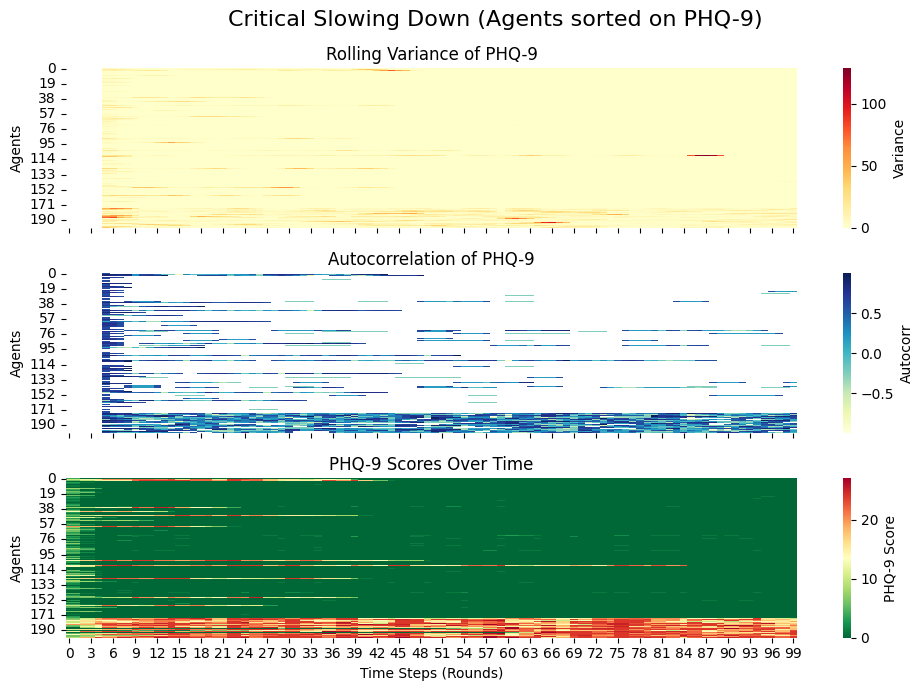

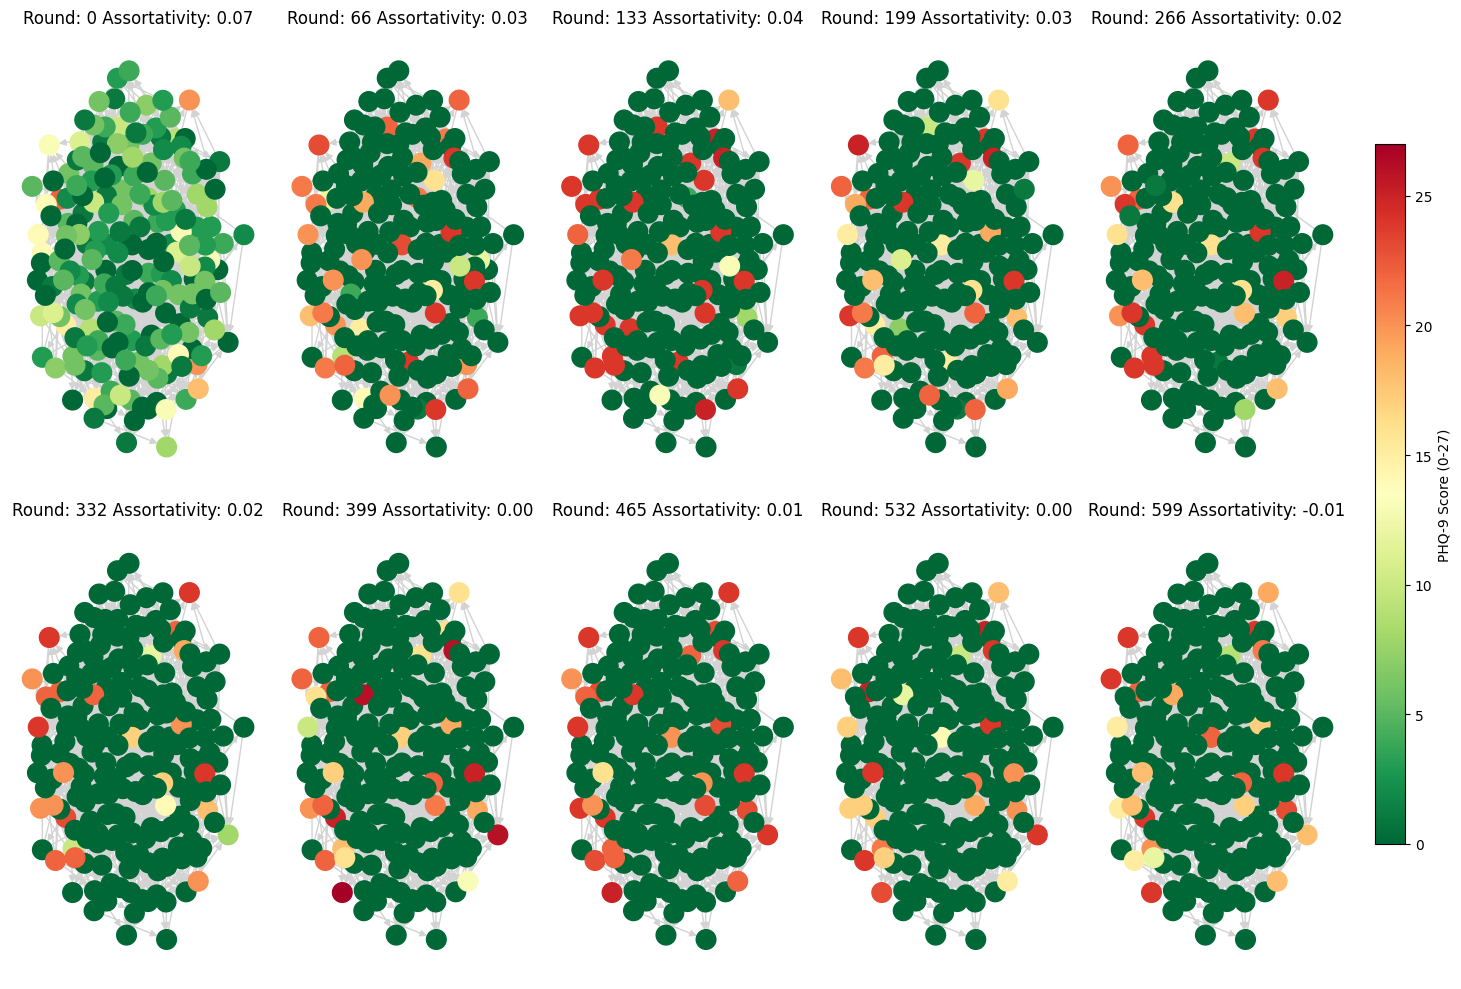

Saving visualizations to directory: plots/networks/basis/sda/directed/1_0_d6_dim2/rounds600_N200/seed_78 filename: _78


In [4]:
all_networks_results = main(args, None, states = ["basis"])
network_results = all_networks_results["basis"][0]
network = network_results["network"]
running_fracs = network_results["running_fracs"]
fracs_dist_step = network_results["fracs_dist_step"]
path_manager = PathManager(network=network)

cd_results = metrics.all_agent_phq9_cd(network, window_size=6, shift=6)

# Get paths
data_path = path_manager.get_run_directory(is_plot=False)
plot_path = path_manager.get_run_directory(is_plot=True)
data_filename = path_manager.get_network_filename()
plot_filename = path_manager.get_plot_name()

vis.plot_agent_cd_heatmaps(network, window=6, cd_results=cd_results, metric_name="PHQ-9", path=plot_path, filename=plot_filename, shift=6)

#Maybe bit ugly here but aggregate degree weighted phq9 scores
deg_w_phq9 = metrics.degree_weighted_mean(network)
vis.plot_degree_weighted_phq9(np.array([deg_w_phq9]), plot_path, plot_filename, save=args.save)
call_visualizations(
    network, 
    plot_path, 
    plot_filename, 
    args, 
    running_fracs, 
    fracs_dist_step)

# pca_visualize(all_networks_results, plot_path, plot_filename, args, num_steps=30, shift=5)

### Create graph and visualize distributions, metrics, and network

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import powerlaw

def create_graph_from_network(network, round=0, graph=None):
    if graph is None:
        if network.directed:
            graph = nx.DiGraph()
        else:
            graph = nx.Graph()

        for agent in network.all_agents:
            graph.add_node(agent.ID, mood=0)
        for connection in network.connections:
            graph.add_edge(connection[0].ID, connection[1].ID)
    
    mood_dist = {}
    for agent in network.all_agents:
        agent_mood = agent.all_phq9_sumscores[round]
        graph.nodes[agent.ID]["mood"] = agent_mood
        mood_dist[agent_mood] = mood_dist.get(agent_mood, 0) + 1
    try:
        assortativity = nx.numeric_assortativity_coefficient(graph, "mood")
    except Exception:
        assortativity = np.nan
    return graph, assortativity, mood_dist	

print("GPU available:", torch.cuda.is_available())

GPU available: False


In [6]:
#============= Semantic Entrainment & Vector Assortativity =============#

def plot_semantic_entrainment(network, mentalbert=True, path="", filename="", save=False, show_fig=True):
    """
    Calculates and plots Semantic Entrainment and Vector Assortativity over time.

    For each timestep:
    - Local Similarity: cosine similarity between each agent's tweet embedding and the
      mean embedding of their direct neighbors (all adjacent agents, regardless of
      edge direction).
    - Global Similarity: cosine similarity between each agent's tweet embedding and the
      mean embedding of the full population at that timestep (excluding self) — serves
      as a random/structural baseline for vector assortativity.

    If local similarity persistently exceeds global similarity, the network exhibits
    positive semantic assortativity (entrainment): connected agents converge in content.

    Args:
        network: Network object with .all_agents, .connections, .directed, .iterations.
        mentalbert (bool): If True, use MentalBERT embeddings; else use all-MiniLM-L6-v2.
        path (str): Directory to save the figure.
        filename (str): Filename suffix for the saved figure.
        save (bool): Whether to save the figure.
        show_fig (bool): Whether to call plt.show().

    Returns:
        fig, ax, metrics_dict — where metrics_dict contains
        'mean_local', 'std_local', 'mean_global' as np.ndarrays of length T.
    """
    from scipy.spatial.distance import cosine as cosine_dist
    import utils.metrics as _metrics
    from utils.format_config import FC

    # --- Build NetworkX graph for neighbor lookups ---
    if network.directed:
        graph = nx.DiGraph()
    else:
        graph = nx.Graph()
    for agent in network.all_agents:
        graph.add_node(agent.ID)
    for connection in network.connections:
        graph.add_edge(connection[0].ID, connection[1].ID)

    id_to_idx = {agent.ID: i for i, agent in enumerate(network.all_agents)}
    T = min(len(agent.tweethistory) for agent in network.all_agents)

    # --- Batch-embed all unique valid tweets at once ---
    print("Collecting unique tweets for embedding...")
    unique_tweets = list({
        agent.tweethistory[t]
        for agent in network.all_agents
        for t in range(T)
        if agent.tweethistory[t] and agent.tweethistory[t] != FC.NO_CONTENT
    })
    if not unique_tweets:
        print("No valid tweets found in the network.")
        return None, None, {}

    model = _metrics.generate_sbert_model(mentalbert=mentalbert)
    print(f"Embedding {len(unique_tweets)} unique tweets...")
    raw_embs = model.encode(unique_tweets, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
    tweet_to_emb = dict(zip(unique_tweets, raw_embs))

    # --- Pre-build agent × timestep embedding lookup: list[list[ndarray|None]] ---
    agent_embs = []
    for agent in network.all_agents:
        row = []
        for t in range(T):
            tw = agent.tweethistory[t]
            row.append(tweet_to_emb.get(tw) if (tw and tw != FC.NO_CONTENT) else None)
        agent_embs.append(row)

    # --- Compute per-timestep similarity metrics ---
    mean_local_sims, std_local_sims, mean_global_sims = [], [], []
    print("Computing semantic entrainment per timestep...")
    for t in range(T):
        # Stack valid embeddings for this timestep
        valid_idx = [i for i in range(len(network.all_agents)) if agent_embs[i][t] is not None]
        if len(valid_idx) < 2:
            mean_local_sims.append(np.nan)
            std_local_sims.append(np.nan)
            mean_global_sims.append(np.nan)
            continue

        valid_embs = np.stack([agent_embs[i][t] for i in valid_idx])  # (N_valid, D)
        pop_sum = valid_embs.sum(axis=0)
        N = len(valid_idx)

        local_sims, global_sims = [], []
        for i, agent in enumerate(network.all_agents):
            emb = agent_embs[i][t]
            if emb is None:
                continue

            # Global (leave-one-out): O(1) using precomputed sum
            global_mean = (pop_sum - emb) / (N - 1)
            global_sims.append(1.0 - cosine_dist(emb, global_mean))

            # Local: mean embedding of neighbors whose content this agent is exposed to.
            # For directed graphs, only predecessors (incoming edges) matter for
            # lexical entrainment — those are the agents sending content to this agent.
            # For undirected graphs, all neighbors are equivalent.
            sources = graph.predecessors(agent.ID) if network.directed else graph.neighbors(agent.ID)
            neighbor_embs = [
                agent_embs[id_to_idx[nid]][t]
                for nid in sources
                if id_to_idx.get(nid) is not None and agent_embs[id_to_idx[nid]][t] is not None
            ]
            if neighbor_embs:
                local_mean = np.mean(neighbor_embs, axis=0)
                local_sims.append(1.0 - cosine_dist(emb, local_mean))

        mean_local_sims.append(np.mean(local_sims) if local_sims else np.nan)
        std_local_sims.append(np.std(local_sims) if local_sims else np.nan)
        mean_global_sims.append(np.mean(global_sims) if global_sims else np.nan)

    # --- Plot ---
    mean_local = np.array(mean_local_sims)
    std_local = np.array(std_local_sims)
    mean_global = np.array(mean_global_sims)
    timesteps = np.arange(T)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(timesteps, mean_local, color='teal', linewidth=2, label='Mean Local Cosine Similarity')
    ax.fill_between(
        timesteps, mean_local - std_local, mean_local + std_local,
        color='teal', alpha=0.2, label='±1 SD (Local)'
    )
    ax.plot(timesteps, mean_global, color='gray', linewidth=1.5, linestyle='--',
            label='Mean Global Cosine Similarity (baseline)')
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title("Semantic Entrainment & Vector Assortativity over Time")
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save and path and filename:
        plt.savefig(f"{path}/semantic_entrainment_{filename}.png", dpi=300, bbox_inches="tight")
    if show_fig:
        plt.show()
    plt.close()

    return fig, ax, {"mean_local": mean_local, "std_local": std_local, "mean_global": mean_global}

fig, ax, metrics_dict = plot_semantic_entrainment(network, mentalbert=True, path=plot_path, filename=plot_filename, save=args.save)

Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[2026-04-05 20:55:51] INFO SentenceTransformer.py:219: Use pytorch device_name: cpu


Embedding 116338 unique tweets...


Batches:   0%|          | 6/1818 [01:48<9:06:00, 18.08s/it] 


KeyboardInterrupt: 

### Animation

In [7]:
def animate_mood_distribution(network, interval=200, save_path=None, save_fig=False, show_fig=False):
    fig, ax = plt.subplots(figsize=(5, 5))
    
    
    graph, assortativity, initial_dist = create_graph_from_network(network, round=0)
    # pos = nx.spring_layout(graph, seed=42) # Seed ensures reproducibility
    
    # nodes = nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=100, 
    #                                node_color=[graph.nodes[n]['mood'] for n in graph.nodes],
    
    #                                cmap=plt.cm.RdYlGn_r, vmin=0, vmax=27)
    # edges = nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.3)

    x_bins = np.arange(0, 28) # PHQ-9 range
    counts = [initial_dist.get(i, 0)/len(network.all_agents) for i in x_bins]
    bars = ax.bar(x_bins, counts, color='teal', edgecolor='black')
    
    ax.set_ylim(0, 1)
    ax.set_xlabel("PHQ-9 Score")
    ax.set_ylabel("Mood Distribution")
    title = ax.set_title("Mood Distribution Evolution")

    def update(frame):
        # Update the graph data for the specific round
        _, assortativity, mood_dist = create_graph_from_network(network, round=frame, graph=graph)
     
        for i, bar in enumerate(bars):
            bar.set_height(mood_dist.get(x_bins[i], 0)/len(network.all_agents))
        
        all_moods = []
        for score, count in mood_dist.items():
            all_moods.extend([score] * int(count))
            
        # Calculate powerlaw alpha
        try:
            fit = powerlaw.Fit(all_moods, discrete=True, verbose=False)
            alpha = fit.alpha
        except:
            alpha = 0
            
        title.set_text(f"Round {frame} | Assortativity: {assortativity:.3f}, alpha: {alpha:.2f}")
        return bars

    total_rounds = len(network.all_agents[0].all_phq9_sumscores)
    ani = FuncAnimation(fig, update, frames=range(total_rounds), 
                        interval=interval, blit=True)
    if show_fig:
        plt.show()

    if save_fig:
        full_path = os.path.join(save_path, "mood_distribution.gif")
        print(f"Saving animation to {full_path}")
        ani.save(full_path, writer='pillow')
        
    plt.show()
    return ani

def animate_network_evolution(network, interval=10, save_path=None, save_fig=False, show_fig=False):
    fig, ax = plt.subplots(figsize=(5, 5))
    
    graph, assortativity, _ = create_graph_from_network(network, round=0)
    pos = nx.kamada_kawai_layout(graph)

    if len(network.all_agents) <= 50:
        # font_size = 10
        # show_labels = True
        node_size = 400
    else:
        # font_size = max(2, 400 // len(network.all_agents))
        node_size = max(20, 40000 // len(network.all_agents))
        # show_labels = False

    
    cmap = plt.cm.RdYlGn_r
    nodes = nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=node_size, 
                                   node_color=[graph.nodes[n]['mood'] for n in graph.nodes],
                                   cmap=cmap, vmin=0, vmax=27, node_shape='o')
    edges = nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.3, edge_color='lightgray', width=1)

    title = ax.set_title("Network Mood Evolution")
    
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])



    # Add a colorbar to indicate the scale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=27))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label='PHQ-9 Score (0-27)')
    
    plt.axis('off')

    def update(frame):
        # Update the graph data for the specific round
        nonlocal graph
        graph, assortativity, _ = create_graph_from_network(network, round=frame, graph=graph)
     
        new_colors = [graph.nodes[n]['mood'] for n in graph.nodes]
        nodes.set_array(np.array(new_colors))

        title.set_text(f"Round {frame} | Assortativity: {assortativity:.3f}")

        return nodes, title

    total_rounds = len(network.all_agents[0].all_phq9_sumscores)
    ani = FuncAnimation(fig, update, frames=range(total_rounds), 
                        interval=interval, blit=True)
    if show_fig:
        plt.show()

    if save_fig:
        full_path = os.path.join(save_path, "network_evolution.gif")
        print(f"Saving animation to {full_path}")
        ani.save(full_path, writer='pillow')
    
    if show_fig:
        plt.show()
    return ani

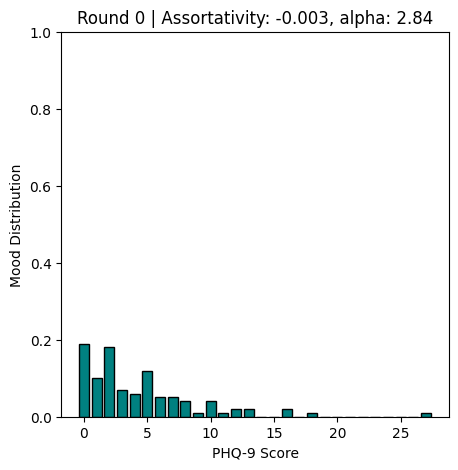

[2026-02-25 16:46:22] INFO animation.py:1076: Animation.save using <class 'matplotlib.animation.PillowWriter'>


Saving animation to plots/networks/basis/sda/directed/1_0_d6_dim2/rounds200_N100/seed_73/mood_distribution.gif


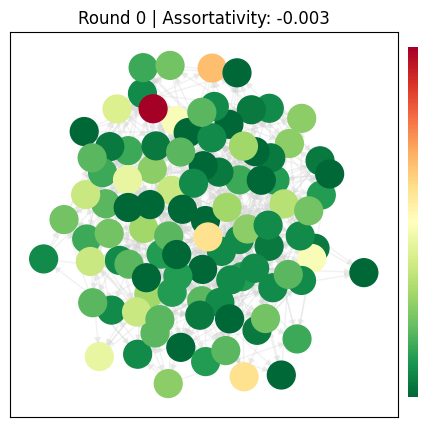

[2026-02-25 16:46:49] INFO animation.py:1076: Animation.save using <class 'matplotlib.animation.PillowWriter'>


Saving animation to plots/networks/basis/sda/directed/1_0_d6_dim2/rounds200_N100/seed_73/network_evolution.gif


In [6]:
animate_mood_distribution(network, interval=50, save_path=plot_path, save_fig=True, show_fig=True)
animate_network_evolution(network, interval=10, save_path=plot_path, save_fig=True, show_fig=True)

In [ ]:
# COSINE SIMILARITY ANALYSIS

### Phase Plot for phqq9 and Homophily

TypeError: draw_networkx_nodes() got an unexpected keyword argument 'show_labels'

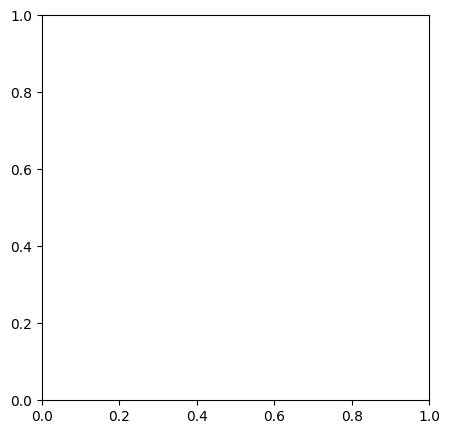

In [ ]:



def plot_phase_dw_phq9_homophily(network, ax=None, label=None, path="", filename="", save=False, show_fig=False):
    """
    Phase plot: x = degree-weighted PHQ-9, y = PHQ-9 assortativity (homophily), over time.

    Args:
        network: Network after a run (has all_phq9_sumscores, connections).
        ax: matplotlib axis; if None, create new figure.
        label: Optional legend label.
        path, filename: Used if save=True.
        save, show_fig: Whether to save or show the figure.
    """
    # X-axis: degree-weighted PHQ-9 (one value per round), same as in metrics
    dw_phq9 = metrics.degree_weighted_mean(network)
    min_rounds = len(dw_phq9)

    # if network.directed:
    #     graph = nx.DiGraph()
    # else:
    #     graph = nx.Graph()

    # for agent in network.all_agents:
    #     graph.add_node(agent.ID, mood=0)
    # for connection in network.connections:
    #     graph.add_edge(connection[0].ID, connection[1].ID)
    

    assortativities = []
    graph = None
    for t in range(min_rounds):
        graph, assortativity, _ = create_graph_from_network(network, round=t, graph=graph)
        assortativities.append(assortativity)

    assortativities = np.array(assortativities)

    if ax is None:
        fig, ax = plt.subplots()
    plot_kw = {"label": label, "alpha": 0.8}
    ax.plot(dw_phq9, assortativities, **plot_kw)
    ax.set_xlabel("Degree-weighted PHQ-9")
    ax.set_ylabel("PHQ-9 assortativity (homophily)")
    ax.set_title("Phase plot: degree-weighted PHQ-9 vs homophily")
    if label is not None:
        ax.legend()
    ax.grid(True, alpha=0.3)
    if save and path and filename:
        ax.figure.savefig(f"{path}/phase_dw_phq9_homophily_{filename}.png", dpi=300, bbox_inches="tight")
    if show_fig:
        plt.show()
    return ax



In [ ]:
# Compare phase plots across different homophily settings (dim, alpha); same degree etc.
# Lines are coloured by alpha value.
import copy


# Define (dim, alpha) combinations to compare (degree and other args stay from `args`)
dims_to_compare = [2]           # e.g. [2], [2, 3]
alphas_to_compare = [1.0]  # e.g. [0.5, 1.0, 2.0]

show_fig = True

def phase_plot_homophily_phq9(dims_to_compare, alphas_to_compare, path="", filename="", save=False, show_fig=False):
    """
    Phase plot: x = degree-weighted PHQ-9, y = PHQ-9 assortativity (homophily), over time.

    Args:
        network: Network after a run (has all_phq9_sumscores, connections).
     """

    fig, ax = plt.subplots(figsize=(8, 6))

    for dim in dims_to_compare:
        for alpha in alphas_to_compare:
            args_run = copy.copy(args)
            args_run.dim = dim
            args_run.alpha = alpha

            # retrieve network (needs to be already run)
            all_networks_results = main(args_run, None, states = ["basis"])
            network_results = all_networks_results["basis"][0]
            network = network_results["network"]

            # plot
            plot_phase_dw_phq9_homophily(
                network, ax=ax,
                label=f"α={alpha}, dim={dim}",
                show_fig=False,
            )
            
            # set axes labels
            ax.set_xlabel("Degree-weighted PHQ-9")
            ax.set_ylabel("PHQ-9 assortativity (homophily)")
            ax.set_title("Phase plot: degree-weighted PHQ-9 vs homophily")
            ax.legend(loc="best", fontsize=8)
            plt.tight_layout()
    if save:
        plt.savefig(f"{path}/phase_plot_homophily_phq9_{filename}.png", dpi=300, bbox_inches="tight")
    if show_fig:
        plt.show()
phase_plot_homophily_phq9(dims_to_compare, alphas_to_compare, path="", filename="", save=False, show_fig=False)

In [ ]:
# create network based on args
network, _, _ = run_simulation(args)
vis.print_network_phq9(network, show_fig=True)

In [ ]:
vis.print_network_phq9(network, show_fig=True)


### Generate network and run simulation

In [ ]:
print("Starting simulation via imported function...")
all_networks_results = sim_script.main(args, pipe, states)

#### Visualize CDS

In [ ]:
# Visualizing the first seed of the first state
target_state = states_to_run[0]
run_index = 0 # 0 for the first seed

if target_state in all_networks_results:
    network_data = all_networks_results[target_state][run_index]
    
    network = network_data["network"]
    running_fracs = network_data["running_fracs"]
    fracs_dist_step = network_data["fracs_dist_step"]
    
    # Initialize PathManager with the specific network instance
    path_manager = PathManager(network=network)
    
    data_path = path_manager.get_run_directory(is_plot=False)
    plot_path = path_manager.get_run_directory(is_plot=True)
    data_filename = path_manager.get_network_filename()
    plot_filename = path_manager.get_plot_name()
    
    print(f"Visualizing results for state: {target_state}")
    
    # Print tweet histories
    metrics.print_histories(network, file_dir=data_path, file_name=data_filename, save=args.save)
    
    # Standard visualizations (CDS, frequency, network,)
    call_visualizations(network, plot_path, plot_filename, args, running_fracs, fracs_dist_step)
    
    # PCA Visualization (if large enough simulation is run)
    # pca_visualize(all_networks_results, plot_path, plot_filename, args)
else:
    print(f"No results found for state {target_state}")